# Pipeline scikit-learn — Dataset Iris

Flusso completo: **EDA → Preprocessing → Pipeline → Addestramento → Confronto modelli**

Modelli: Logistic Regression vs Random Forest

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Librerie caricate correttamente.')

Librerie caricate correttamente.


---
## 1. Caricamento dati

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Shape: {df.shape}')
print(f'Classi: {df.species.unique()}')
df.head()

Shape: (150, 5)
Classi: ['setosa', 'versicolor', 'virginica']
Categories (3, str): ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## 2. EDA

In [4]:
# Statistiche descrittive
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
# Valori mancanti
print('Valori mancanti:')
print(df.isnull().sum())

Valori mancanti:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


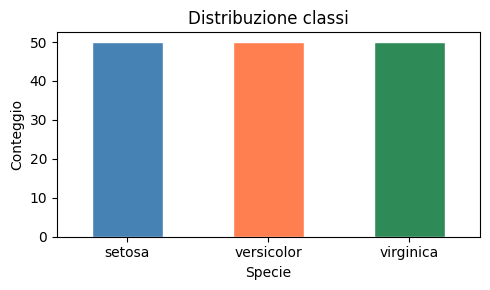

In [6]:
# Distribuzione delle classi
plt.figure(figsize=(5, 3))
df['species'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
plt.title('Distribuzione classi')
plt.xlabel('Specie')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

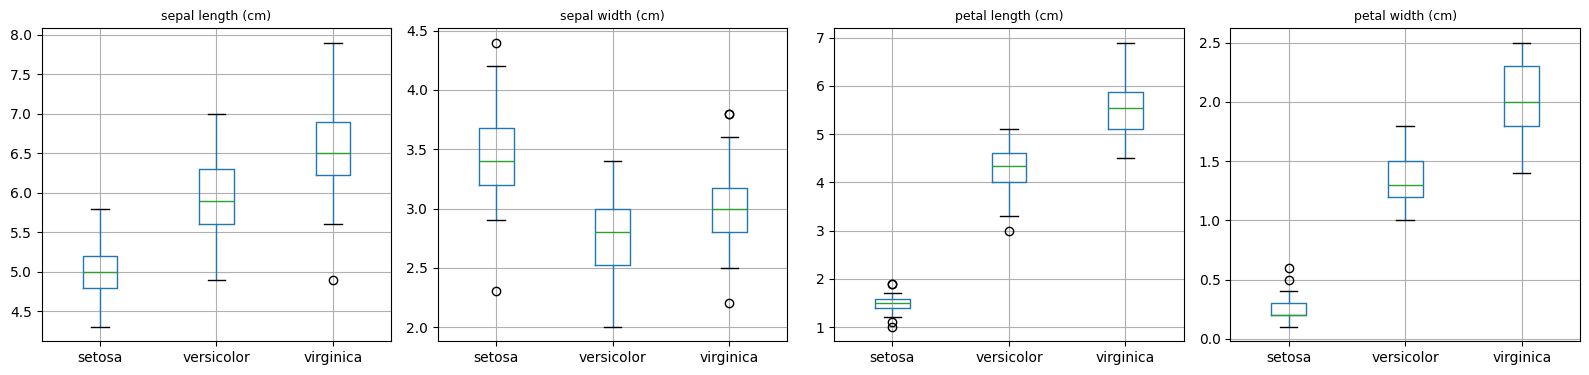

In [7]:
# Boxplot feature per classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, iris.feature_names):
    df.boxplot(column=col, by='species', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

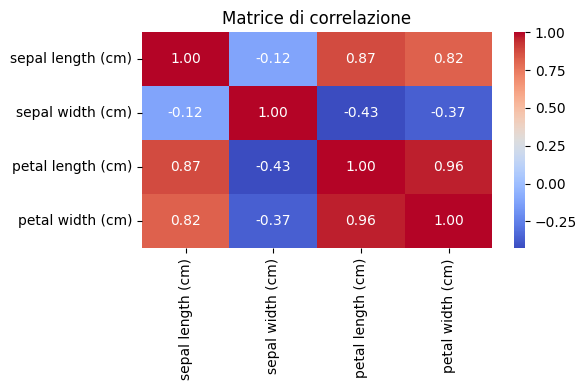

In [8]:
# Correlazione tra feature
plt.figure(figsize=(6, 4))
sns.heatmap(df.drop(columns='species').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

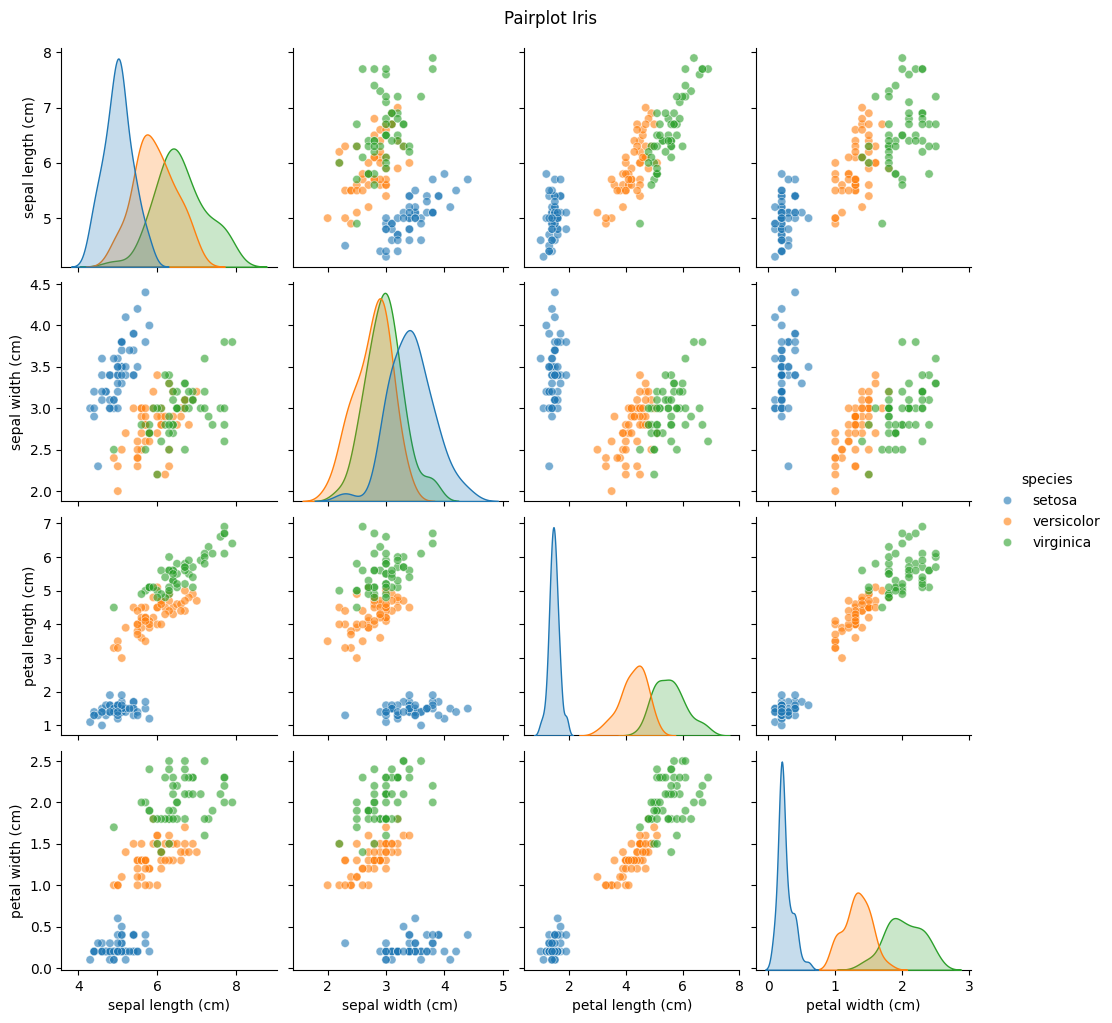

In [9]:
# Pairplot — relazione tra tutte le coppie di feature
sns.pairplot(df, hue='species', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Iris', y=1.02)
plt.show()

---
## 3. Preprocessing — Train/Test Split

In [10]:
X = df.drop(columns='species')
y = iris.target  # 0, 1, 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} campioni')
print(f'Test:  {X_test.shape[0]} campioni')

Train: 120 campioni
Test:  30 campioni


---
## 4. Pipeline

Una `Pipeline` incapsula in sequenza tutti gli step: prima lo **scaling**, poi il **modello**.
Questo garantisce che lo scaler venga fittato solo sul train set, evitando il *data leakage*.

In [12]:
# Pipeline 1 — Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=200, random_state=42))
])

# Pipeline 2 — Random Forest (non necessita di scaling, ma lo teniamo per uniformità)
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

print('Pipeline create correttamente.')
print(pipe_lr)

Pipeline create correttamente.
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=200, random_state=42))])


# ESERCIZIO
Implementare la ricerca degli iperparametri per trovare quelli migliori per ciascuna pipeline

In [ ]:
from sklearn.model_selection import GridSearchCV

# Griglia parametri per Logistic Regression
param_grid_lr = {
    pass
}

# Griglia parametri per Random Forest
param_grid_rf = {
    'model__n_estimators': pass,
    'model__max_depth':    pass
}

# GridSearch su entrambe le pipeline
grid_lr = pass
grid_rf = pass

grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print(f'Migliori parametri LR: {grid_lr.best_params_}')
print(f'Migliori parametri RF: {grid_rf.best_params_}')



Migliori parametri LR: {'model__C': 10}
Migliori parametri RF: {'model__max_depth': 3, 'model__n_estimators': 50}
best estimator Logistic Regression: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=10, max_iter=200, random_state=42))])


---
## 5. Addestramento e valutazione

In [29]:
# Fit
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Accuracy sul test set
acc_lr = pipe_lr.score(X_test, y_test)
acc_rf = pipe_rf.score(X_test, y_test)

print(f'Logistic Regression — Test Accuracy: {acc_lr:.3f}')
print(f'Random Forest       — Test Accuracy: {acc_rf:.3f}')

Logistic Regression — Test Accuracy: 0.933
Random Forest       — Test Accuracy: 0.900


In [14]:
# Cross-validation (5 fold) — più affidabile della singola accuracy
cv_lr = cross_val_score(pipe_lr, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='accuracy')

print(f'Logistic Regression — CV: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')
print(f'Random Forest       — CV: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')

Logistic Regression — CV: 0.960 ± 0.039
Random Forest       — CV: 0.967 ± 0.021


In [15]:
# Classification report
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

=== Logistic Regression ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== Random Forest ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



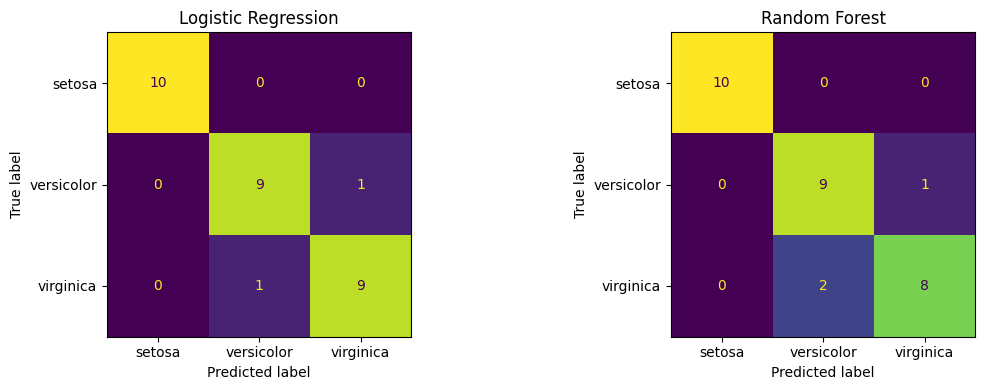

In [16]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## 6. Confronto finale

            Modello  Test Accuracy  CV Mean  CV Std
Logistic Regression          0.933    0.960   0.039
      Random Forest          0.900    0.967   0.021


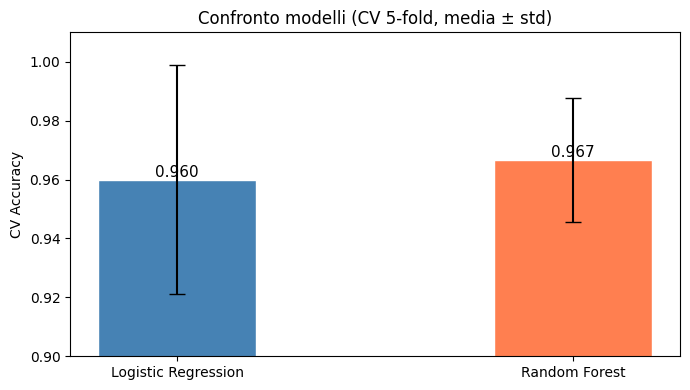

In [17]:
risultati = pd.DataFrame({
    'Modello':       ['Logistic Regression', 'Random Forest'],
    'Test Accuracy': [acc_lr, acc_rf],
    'CV Mean':       [cv_lr.mean(), cv_rf.mean()],
    'CV Std':        [cv_lr.std(), cv_rf.std()]
}).round(3)

print(risultati.to_string(index=False))

# Grafico
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
bars = ax.bar(x, [cv_lr.mean(), cv_rf.mean()],
              yerr=[cv_lr.std(), cv_rf.std()],
              color=['steelblue', 'coral'], width=0.4,
              capsize=6, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.set_ylim(0.9, 1.01)
ax.set_ylabel('CV Accuracy')
ax.set_title('Confronto modelli (CV 5-fold, media ± std)')
for bar, val in zip(bars, [cv_lr.mean(), cv_rf.mean()]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Riepilogo

| Step | Cosa abbiamo fatto |
|---|---|
| **EDA** | Distribuzione classi, boxplot, correlazione, pairplot |
| **Split** | 80% train / 20% test, stratificato per classe |
| **Pipeline** | StandardScaler → Modello (niente data leakage) |
| **Valutazione** | Accuracy, cross-validation, classification report, confusion matrix |
| **Confronto** | Logistic Regression vs Random Forest |

Su Iris entrambi i modelli performano molto bene — su dataset più complessi le differenze sarebbero più evidenti.